#TAREA 1
## Leonardo Garcia Muñoz

### Los textos son 2 archivos .txt, uno con las letras de album Dangerous de 1991 de Michael Jackson, otro con su siguiente album HIStory de 1995 (dos de mis discos favoritos)

In [2]:
#Leemos los txt que tienen las letras de ambos albumes musicales
def leer_letras(ruta_archivo):
    with open(ruta_archivo, "r", encoding="utf-8") as f:
        return f.read()

texto_dangerous = leer_letras("/content/Dangerous_Album_Lyrics.txt")
texto_history = leer_letras("/content/HIStory_Album_Lyrics.txt")

print(f"Dangerous: {len(texto_dangerous)} caracteres")
print(f"HIStory: {len(texto_history)} caracteres")

Dangerous: 36494 caracteres
HIStory: 35033 caracteres


In [3]:
# Vistazo rápido al contenido
print(texto_dangerous[:300])

Jam
Nation to nation, all the world must come together
Face the problems that we see then maybe somehow we can work it out
I asked my neighbor for a favor, she said later
What has come of all the people, have we lost love of what it's about?
I have to find my peace 'cause no one seems to let me be
F


In [4]:
print(texto_history[:300])

Scream

Hoo
No
Hoo, hee
Hoo

I'm tired of injustice, ah
I'm tired of the schemes, ah
The lies are disgustin', ah
So what does it mean? Damn it
Kickin' me down, ah
I got to get up, ah
As jacked as it sounds, ah
The whole system sucks, damn it
Hoo
Hoo-hoo

Peek in the shadow (Hoo-hoo)
I come into the 


In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt_tab')
def preprocesar(texto, idioma='english', palabras_extra=None):
    texto_limpio = re.sub(r'[^\w\s]', '', texto.lower())
    tokens = word_tokenize(texto_limpio)
    stop_words = set(stopwords.words(idioma))
    if palabras_extra:
        stop_words.update(palabras_extra)
    tokens_filtrados = [t for t in tokens if t not in stop_words and not t.isdigit()]
    return tokens_filtrados

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [6]:
#ahora usemos la funcion
tokens_dangerous = preprocesar(texto_dangerous, idioma='english')
tokens_history = preprocesar(texto_history, idioma='english')


In [7]:
print(f"Dangerous: {len(tokens_dangerous)} tokens después de limpieza")
print(f"HIStory: {len(tokens_history)} tokens después de limpieza")


Dangerous: 3792 tokens después de limpieza
HIStory: 3617 tokens después de limpieza


In [8]:
print("\nEjemplo Dangerous:", tokens_dangerous[:15])
print("Ejemplo HIStory:", tokens_history[:15])


Ejemplo Dangerous: ['jam', 'nation', 'nation', 'world', 'must', 'come', 'together', 'face', 'problems', 'see', 'maybe', 'somehow', 'work', 'asked', 'neighbor']
Ejemplo HIStory: ['scream', 'hoo', 'hoo', 'hee', 'hoo', 'im', 'tired', 'injustice', 'ah', 'im', 'tired', 'schemes', 'ah', 'lies', 'disgustin']


In [9]:
import pandas as pd
from collections import Counter
#Estadistica descriptiva basica
def estadisticas_basicas(texto, tokens, nombre):
    palabras_unicas = set(tokens)
    longitudes = [len(t) for t in tokens]

    stats = {
        "Álbum": nombre,
        "Caracteres totales": len(texto),
        "Palabras totales (tokens)": len(tokens),
        "Palabras únicas": len(palabras_unicas),
        "Riqueza léxica (TTR)": round(len(palabras_unicas) / len(tokens), 4),
        "Longitud promedio de palabra": round(sum(longitudes) / len(longitudes), 2),
    }
    return stats

df_stats = pd.DataFrame([
    estadisticas_basicas(texto_dangerous, tokens_dangerous, "Dangerous"),
    estadisticas_basicas(texto_history, tokens_history, "HIStory"),
])
df_stats

,Álbum,Caracteres totales,Palabras totales (tokens),Palabras únicas,Riqueza léxica (TTR),Longitud promedio de palabra
0,Dangerous,36494,3792,793,0.2091,4.60
1,HIStory,35033,3617,926,0.2560,4.91


In [10]:
def top_palabras(tokens, n=15):
    return Counter(tokens).most_common(n)

top_dangerous = top_palabras(tokens_dangerous)
top_history = top_palabras(tokens_history)

print("Top 15 Dangerous:", top_dangerous)
print("\nTop 15 HIStory:", top_history)

Top 15 Dangerous: [('dont', 94), ('give', 85), ('got', 82), ('jam', 67), ('let', 67), ('cant', 64), ('aint', 63), ('remember', 58), ('shes', 57), ('time', 50), ('yeah', 49), ('keep', 48), ('na', 46), ('wants', 46), ('get', 44)]

Top 15 HIStory: [('really', 90), ('dont', 79), ('ah', 63), ('bad', 54), ('anything', 44), ('stop', 43), ('money', 43), ('man', 41), ('us', 41), ('youre', 39), ('scream', 38), ('say', 38), ('na', 37), ('wan', 35), ('thought', 35)]


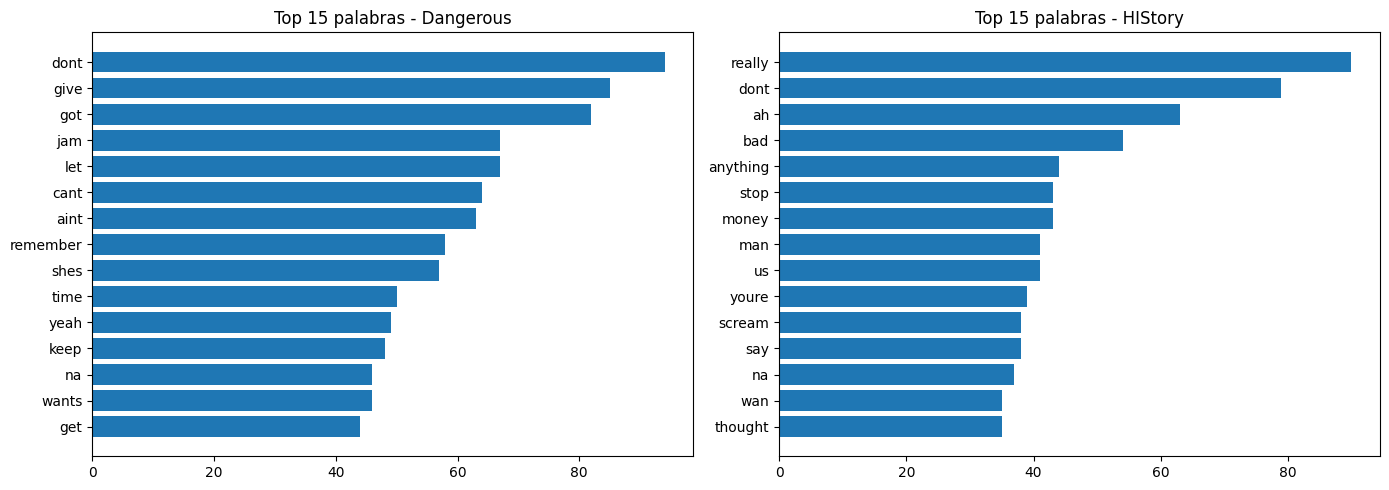

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palabras, frecs = zip(*top_dangerous)
axes[0].barh(palabras, frecs)
axes[0].invert_yaxis()
axes[0].set_title("Top 15 palabras - Dangerous")

palabras, frecs = zip(*top_history)
axes[1].barh(palabras, frecs)
axes[1].invert_yaxis()
axes[1].set_title("Top 15 palabras - HIStory")

plt.tight_layout()
plt.savefig("frecuencias_top15.png", dpi=300, bbox_inches="tight")
plt.show()
files.download("frecuencias_top15.png")

In [12]:
from nltk import bigrams, trigrams

def top_ngramas(tokens, n=2, top=10):
    if n == 2:
        combos = list(bigrams(tokens))
    elif n == 3:
        combos = list(trigrams(tokens))
    return Counter(combos).most_common(top)

print("Bigramas Dangerous:", top_ngramas(tokens_dangerous, n=2))
print("Bigramas HIStory:", top_ngramas(tokens_history, n=2))
print("\nTrigramas Dangerous:", top_ngramas(tokens_dangerous, n=3))
print("Trigramas HIStory:", top_ngramas(tokens_history, n=3))

Bigramas Dangerous: [(('jam', 'aint'), 55), (('wants', 'give'), 46), (('cant', 'let'), 45), (('aint', 'much'), 34), (('wan', 'na'), 33), (('shes', 'got'), 32), (('got', 'look'), 32), (('remember', 'time'), 31), (('keep', 'faith'), 31), (('let', 'get'), 23)]
Bigramas HIStory: [(('wan', 'na'), 35), (('cold', 'man'), 30), (('sneddon', 'cold'), 28), (('really', 'thought'), 24), (('bad', 'bad'), 24), (('stop', 'pressurin'), 23), (('tom', 'sneddon'), 23), (('thought', 'really'), 20), (('really', 'control'), 20), (('anything', 'money'), 20)]

Trigramas Dangerous: [(('jam', 'aint', 'much'), 31), (('shes', 'got', 'look'), 31), (('got', 'look', 'shes'), 22), (('let', 'get', 'away'), 22), (('let', 'cant', 'let'), 22), (('cant', 'let', 'get'), 20), (('cant', 'let', 'cant'), 20), (('ah', 'wants', 'give'), 19), (('make', 'better', 'place'), 19), (('aint', 'much', 'jam'), 17)]
Trigramas HIStory: [(('sneddon', 'cold', 'man'), 28), (('tom', 'sneddon', 'cold'), 23), (('bad', 'bad', 'dont'), 20), (('bad'

In [13]:
import string

def contar_puntuacion(texto):
    contador = Counter(c for c in texto if c in string.punctuation)
    return contador.most_common()

punt_dangerous = contar_puntuacion(texto_dangerous)
punt_history = contar_puntuacion(texto_history)

print("Puntuación Dangerous:", punt_dangerous)
print("Puntuación HIStory:", punt_history)

Puntuación Dangerous: [("'", 608), (',', 578), ('(', 353), (')', 353), ('-', 100), ('?', 97), ('!', 82), (';', 28), ('"', 17), ('[', 5), (']', 5), ('.', 1), (':', 1)]
Puntuación HIStory: [(',', 454), ("'", 418), ('(', 297), (')', 297), ('?', 112), ('-', 103), ('!', 49), ('"', 42), ('[', 8), (']', 8), ('.', 6), (':', 5), (';', 2), ('*', 2), ('&', 1)]


In [14]:
!pip install emoji -q
import emoji

def contar_emojis(texto):
    emojis_encontrados = [c for c in texto if c in emoji.EMOJI_DATA]
    return Counter(emojis_encontrados).most_common()

print("Emojis Dangerous:", contar_emojis(texto_dangerous))
print("Emojis HIStory:", contar_emojis(texto_history))
#Yo hice el txt, yose que no hay emojis pero pues para tener la evidencia en codigo xd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 8.7 MB/s eta 0:00:00
Emojis Dangerous: []
Emojis HIStory: []


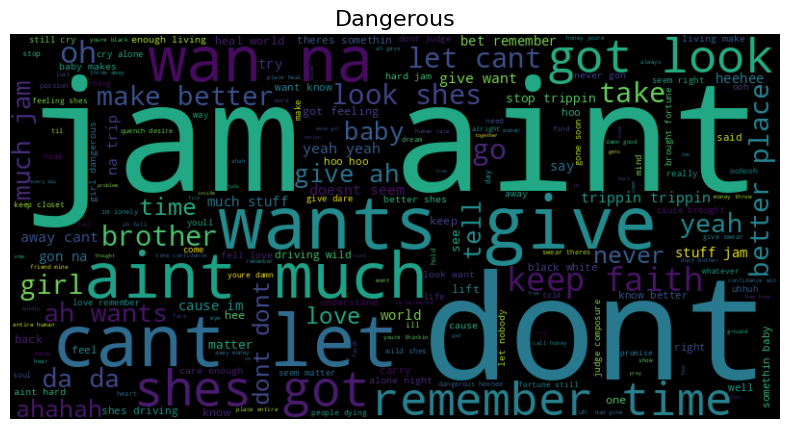

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

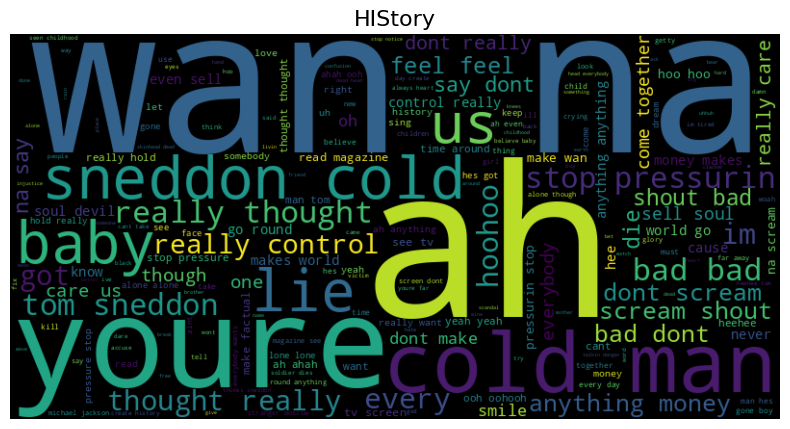

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
!pip install wordcloud -q
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def graficar_wordcloud(tokens, titulo, guardar_como=None):
    texto_wc = " ".join(tokens)
    wc = WordCloud(width=800, height=400, background_color="black",
                    colormap="viridis").generate(texto_wc)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(titulo, fontsize=16)

    if guardar_como:
        plt.savefig(guardar_como, dpi=300, bbox_inches="tight")
    plt.show()

graficar_wordcloud(tokens_dangerous, "Dangerous", guardar_como="wordcloud_dangerous.png")
files.download("wordcloud_dangerous.png")

graficar_wordcloud(tokens_history, "HIStory", guardar_como="wordcloud_history.png")
files.download("wordcloud_history.png")

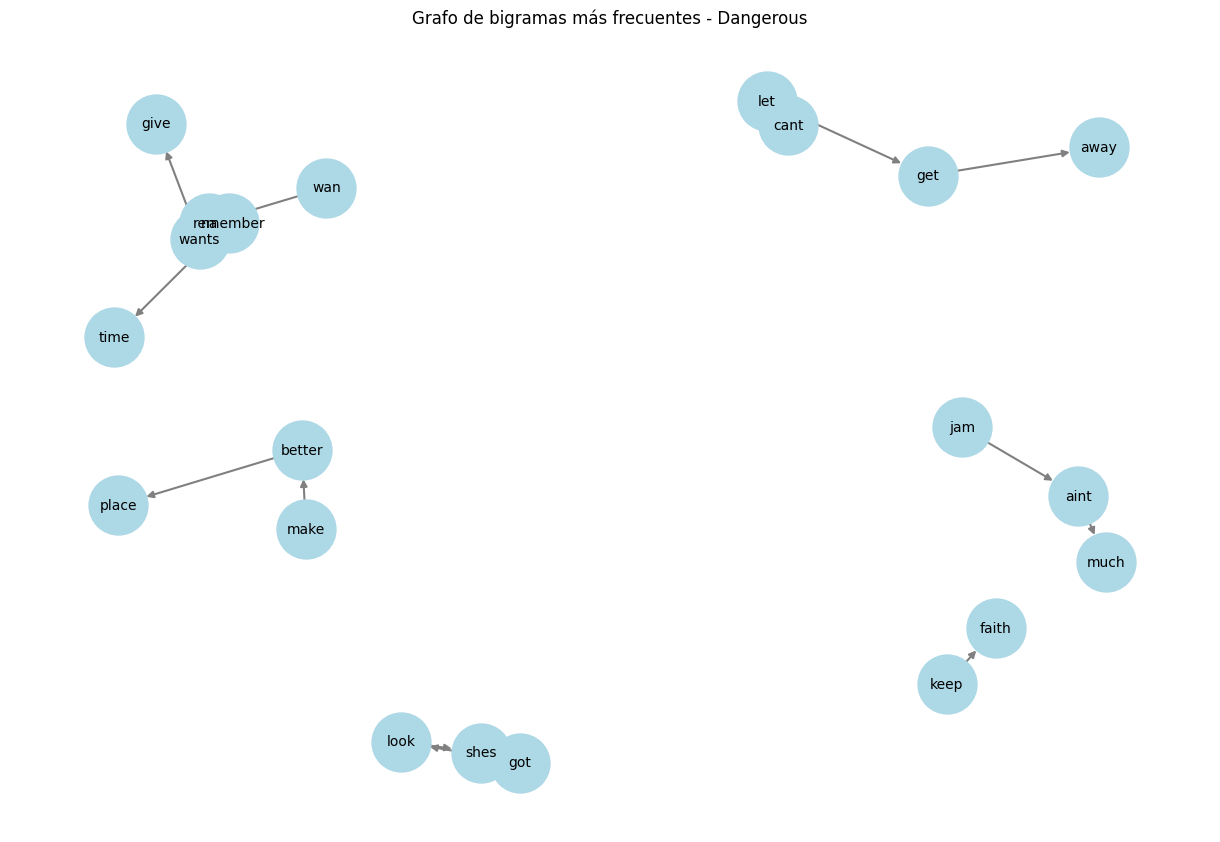

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

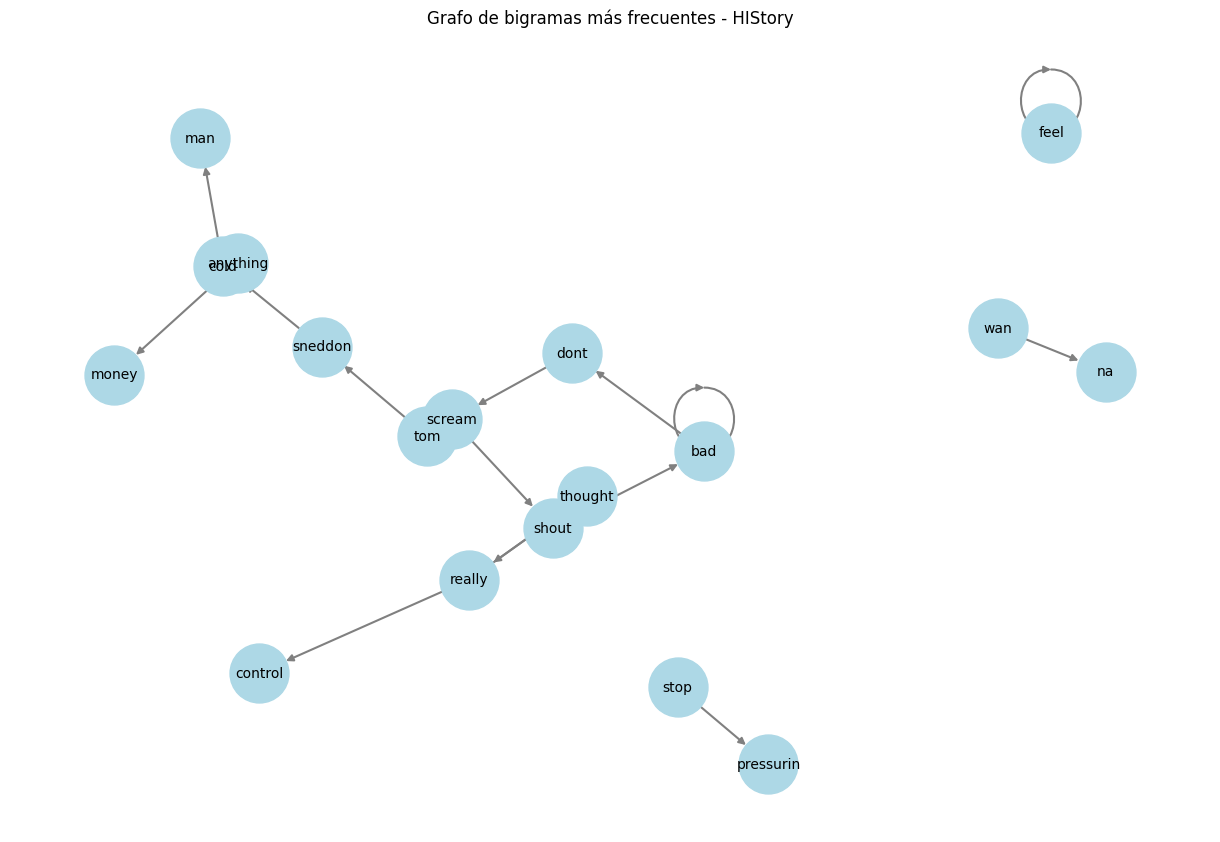

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
import networkx as nx
from nltk import bigrams
from collections import Counter

def graficar_grafo_bigramas(tokens, titulo, top_n=15, min_freq=3, guardar_como=None):
    lista_bigramas = list(bigrams(tokens))
    frecuencias = Counter(lista_bigramas)
    top_bigramas = [(par, f) for par, f in frecuencias.most_common(top_n) if f >= min_freq]

    G = nx.DiGraph()
    for (palabra1, palabra2), peso in top_bigramas:
        G.add_edge(palabra1, palabra2, weight=peso)

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=1.2, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=1800, node_color="lightblue",
            font_size=10, arrows=True, edge_color="gray", width=1.5)
    plt.title(f"Grafo de bigramas más frecuentes - {titulo}")

    if guardar_como:
        plt.savefig(guardar_como, dpi=300, bbox_inches="tight")
    plt.show()

graficar_grafo_bigramas(tokens_dangerous, "Dangerous", guardar_como="bigramas_dangerous.png")
files.download("bigramas_dangerous.png")

graficar_grafo_bigramas(tokens_history, "HIStory", guardar_como="bigramas_history.png")
files.download("bigramas_history.png")

In [18]:
def graficar_grafo_bigramas(tokens, titulo, top_n=15, min_freq=3):
    lista_bigramas = list(bigrams(tokens))
    frecuencias = Counter(lista_bigramas)
    # Filtra bigramas que aparecen muy pocas veces
    top_bigramas = [(par, f) for par, f in frecuencias.most_common(top_n) if f >= min_freq]

    G = nx.DiGraph()
    for (palabra1, palabra2), peso in top_bigramas:
        G.add_edge(palabra1, palabra2, weight=peso)

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=1.2, seed=42)  # k más alto = nodos más separados
    nx.draw(G, pos, with_labels=True, node_size=1800, node_color="lightblue",
            font_size=10, arrows=True, edge_color="gray", width=1.5)
    plt.title(f"Grafo de bigramas más frecuentes - {titulo}")
    plt.show()

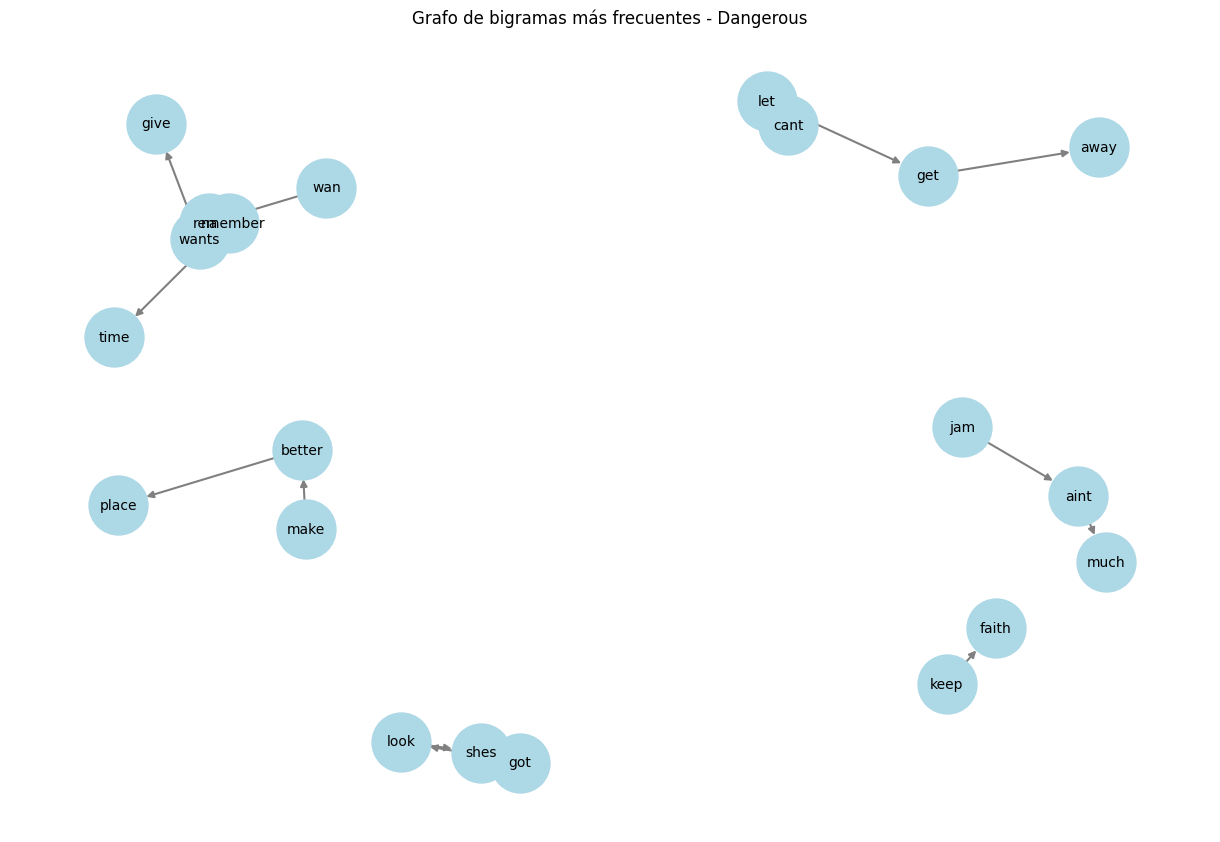

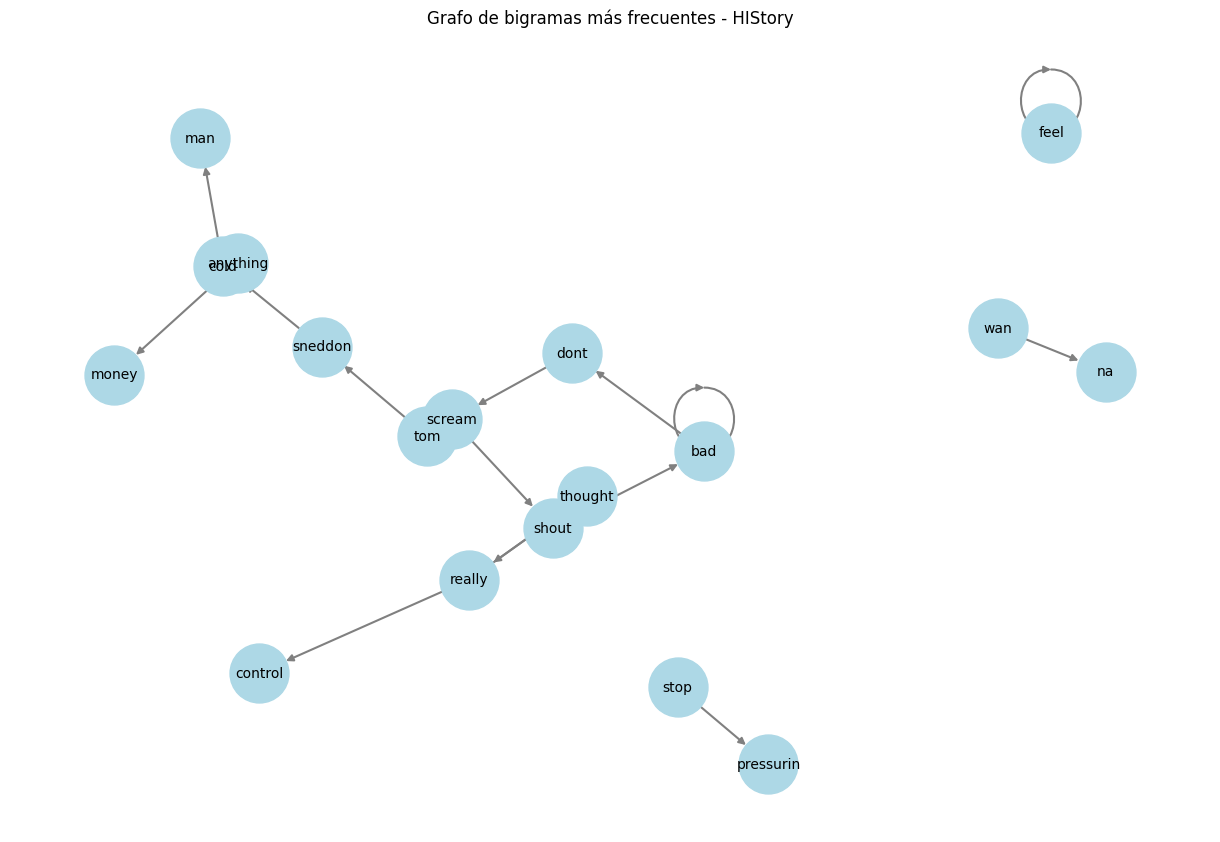

In [19]:
graficar_grafo_bigramas(tokens_dangerous, "Dangerous")
graficar_grafo_bigramas(tokens_history, "HIStory")
#salio igual de extraño xd